In [1]:
import pandas as pd
pd.set_option("display.max_columns", None)
import numpy as np

In [2]:
df = pd.read_parquet("../../data/cleansed/all_flights_2018-2022_cleansed.parquet")

df.shape

(3426007, 52)

In [3]:
df.head()

,FlightDate,Airline,Origin,Dest,CRSDepTime,CRSElapsedTime,Distance,Year,Quarter,Month,DayofMonth,DayOfWeek,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,Flight_Number_Marketing_Airline,Operating_Airline,DOT_ID_Operating_Airline,IATA_Code_Operating_Airline,Tail_Number,Flight_Number_Operating_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,DestCityName,DestState,DestStateFips,DestStateName,DestWac,DepTimeBlk,CRSArrTime,ArrTimeBlk,DistanceGroup,year,target,date,dep_hour,tmpf,vsby,sknt,p01i,relh,gust
0,2018-01-04,Endeavor Air Inc.,ATL,ABY,1037,60.0,145.0,2018,1,1,4,4,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N981EV,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1137,1100-1159,1,2018,On time,2018-01-04,10,24.10,10.000000,14.166667,0.00,54.360,21.0
1,2018-01-13,Endeavor Air Inc.,ATL,ABY,1037,59.0,145.0,2018,1,1,13,6,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8976E,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1136,1100-1159,1,2018,On time,2018-01-13,10,28.90,10.000000,17.200000,0.00,74.760,26.0
2,2018-01-17,Endeavor Air Inc.,ATL,ABY,1037,60.0,145.0,2018,1,1,17,3,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8972E,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1137,1100-1159,1,2018,Cancelled,2018-01-17,10,17.46,0.661765,14.176471,0.39,90.992,19.0
3,2018-01-30,Endeavor Air Inc.,ATL,ABY,1037,60.0,145.0,2018,1,1,30,2,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8946A,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1137,1100-1159,1,2018,On time,2018-01-30,10,30.90,10.000000,16.461538,0.00,60.920,20.0
4,2018-01-13,Endeavor Air Inc.,ATL,EVV,941,87.0,350.0,2018,1,1,13,6,DL,DL_CODESHARE,19790,DL,3299,9E,20363,9E,N8928A,3299,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,11612,1161206,31612,"Evansville, IN",IN,18,Indiana,42,0900-0959,1008,1000-1059,2,2018,Delayed,2018-01-13,9,28.00,10.000000,15.600000,0.00,77.570,27.0


In [4]:
df.isnull().sum().sort_values(ascending=False).head(20)

Tail_Number         19217
CRSElapsedTime          4
FlightDate              0
CRSArrTime              0
OriginWac               0
DestAirportID           0
DestAirportSeqID        0
DestCityMarketID        0
DestCityName            0
DestState               0
DestStateFips           0
DestStateName           0
DestWac                 0
DepTimeBlk              0
ArrTimeBlk              0
OriginStateFips         0
DistanceGroup           0
year                    0
target                  0
date                    0
dtype: int64

In [5]:
df.target.value_counts()

target
On time      2516506
Delayed       811341
Cancelled      98160
Name: count, dtype: int64

In [6]:
df.columns

Index(['FlightDate', 'Airline', 'Origin', 'Dest', 'CRSDepTime',
       'CRSElapsedTime', 'Distance', 'Year', 'Quarter', 'Month', 'DayofMonth',
       'DayOfWeek', 'Marketing_Airline_Network',
       'Operated_or_Branded_Code_Share_Partners', 'DOT_ID_Marketing_Airline',
       'IATA_Code_Marketing_Airline', 'Flight_Number_Marketing_Airline',
       'Operating_Airline', 'DOT_ID_Operating_Airline',
       'IATA_Code_Operating_Airline', 'Tail_Number',
       'Flight_Number_Operating_Airline', 'OriginAirportID',
       'OriginAirportSeqID', 'OriginCityMarketID', 'OriginCityName',
       'OriginState', 'OriginStateFips', 'OriginStateName', 'OriginWac',
       'DestAirportID', 'DestAirportSeqID', 'DestCityMarketID', 'DestCityName',
       'DestState', 'DestStateFips', 'DestStateName', 'DestWac', 'DepTimeBlk',
       'CRSArrTime', 'ArrTimeBlk', 'DistanceGroup', 'year', 'target', 'date',
       'dep_hour', 'tmpf', 'vsby', 'sknt', 'p01i', 'relh', 'gust'],
      dtype='object')

In [7]:
df.target.value_counts(normalize=True)

target
On time      0.734530
Delayed      0.236818
Cancelled    0.028651
Name: proportion, dtype: float64

### Sampling Strategy

Another thing to consider for RF, is to sample data to not train on entire dataset.

Due to the scale of the dataset (~29M flights), we applied a multi-stage sampling strategy. 

Data were first sampled evenly across months to retain seasonal patterns. Next, the contribution of any single origin airport was capped at 5% to prevent dominance by major hubs. Finally, the sample was stratified by the target variable (on-time, delayed, cancelled) on a best-effort basis to improve class balance. This approach maintains temporal, geographic, and outcome diversity while producing a manageable dataset for baseline modeling.



In [11]:
import pandas as pd

# -----------------------------
# CONFIG
# -----------------------------
TOTAL_SAMPLE = 600_000          # target total rows
MAX_ORIGIN_FRAC = 0.05          # no single origin >5%
RANDOM_STATE = 42

# -----------------------------
# PREP
# -----------------------------
df = df.copy()
df["FlightDate"] = pd.to_datetime(df["FlightDate"])
df["month"] = df["FlightDate"].dt.to_period("M").astype(str)

# -----------------------------
# STEP 1: BALANCE MONTHS
# -----------------------------
n_months = df["month"].nunique()
rows_per_month = TOTAL_SAMPLE // n_months

month_samples = []
for m, g in df.groupby("month"):
    month_samples.append(
        g.sample(
            n=min(len(g), rows_per_month),
            random_state=RANDOM_STATE
        )
    )

month_balanced = pd.concat(month_samples, ignore_index=True)

# -----------------------------
# STEP 2: CAP ORIGIN DOMINANCE
# -----------------------------
origin_cap = int(len(month_balanced) * MAX_ORIGIN_FRAC)

origin_balanced = (
    month_balanced
    .groupby("Origin", group_keys=False)
    .apply(
        lambda x: x.sample(
            n=min(len(x), origin_cap),
            random_state=RANDOM_STATE
        )
    )
)

# -----------------------------
# STEP 3: STRATIFY TARGET
# -----------------------------
n_classes = origin_balanced["target"].nunique()
rows_per_class = len(origin_balanced) // n_classes

final_sample = (
    origin_balanced
    .groupby("target", group_keys=False)
    .apply(
        lambda x: x.sample(
            n=min(len(x), rows_per_class),
            random_state=RANDOM_STATE
        )
    )
)

# -----------------------------
# FINAL CHECKS TO ENSURE TRAINING DATA REPRESENTS ENTIRE DATASET WE HAVE
# -----------------------------
print("Final rows:", len(final_sample))
print("\nTarget distribution:")
print(final_sample["target"].value_counts(normalize=True))

print("\nTop origins:")
print(final_sample["Origin"].value_counts(normalize=True).head())

print("\nMonth distribution:")
print(final_sample["month"].value_counts(normalize=True).sort_index())


Final rows: 308970

Target distribution:
target
On time      0.556426
Delayed      0.395239
Cancelled    0.048335
Name: proportion, dtype: float64

Top origins:
Origin
DEN    0.059928
EWR    0.058711
DFW    0.058543
ORD    0.058109
ATL    0.055258
Name: proportion, dtype: float64

Month distribution:
month
2018-01    0.025083
2018-02    0.023135
2018-03    0.024912
2018-04    0.023766
2018-05    0.025336
2018-06    0.025200
2018-07    0.026025
2018-08    0.024430
2018-09    0.022556
2018-10    0.021701
2018-11    0.022960
2018-12    0.022873
2019-01    0.023905
2019-02    0.023614
2019-03    0.022400
2019-04    0.023883
2019-05    0.023604
2019-06    0.024837
2019-07    0.024316
2019-08    0.023792
2019-09    0.021821
2019-10    0.022206
2019-11    0.021756
2019-12    0.023442
2021-01    0.019432
2021-02    0.021494
2021-03    0.019678
2021-04    0.020099
2021-05    0.021332
2021-06    0.023760
2021-07    0.024193
2021-08    0.023847
2021-09    0.021196
2021-10    0.022772
2021-11    0

In [13]:
# -----------------------------
# TRAIN / VAL / TEST SPLIT
# -----------------------------
final_sample = final_sample.sort_values("FlightDate")

n = len(final_sample)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = final_sample.iloc[:train_end]
val_df   = final_sample.iloc[train_end:val_end]
test_df  = final_sample.iloc[val_end:]

# -----------------------------
# CHECKS
# -----------------------------
print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain target distribution:")
print(train_df["target"].value_counts(normalize=True))

print("\nTest target distribution:")
print(test_df["target"].value_counts(normalize=True))

print("\nDate ranges:")
print("Train:", train_df["FlightDate"].min(), "→", train_df["FlightDate"].max())
print("Test :", test_df["FlightDate"].min(), "→", test_df["FlightDate"].max())


Train: (216279, 25)
Val: (46345, 25)
Test: (46346, 25)

Train target distribution:
target
On time      0.568358
Delayed      0.385941
Cancelled    0.045700
Name: proportion, dtype: float64

Test target distribution:
target
On time      0.507164
Delayed      0.434169
Cancelled    0.058667
Name: proportion, dtype: float64

Date ranges:
Train: 2018-01-01 00:00:00 → 2021-07-09 00:00:00
Test : 2022-01-24 00:00:00 → 2022-07-30 00:00:00


In [14]:
val_df = (
    val_df
    .groupby("target", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), 50_000),
        random_state=42
    ))
)


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


## Random Forest Model Baseline

Features based off of EDA:
- Airline
- DeptTimeBlk
- DistanceGroup
- Month
- Dep_Hour
- Weather
- DayofWeek

In [16]:
FEATURES = ["Quarter", "Month", "DayofMonth", "DayOfWeek", "dep_hour", "DepTimeBlk",
    "Airline", "Origin", "Dest", "Distance", "DistanceGroup",
    "tmpf", "vsby", "sknt", "p01i", "relh", "gust"
]

TARGET = "target"


In [17]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Split categorical vs numerical
categorical_features = [
    "DepTimeBlk", "Airline", "Origin", "Dest", "DistanceGroup"
]

numeric_features = [
    "Quarter", "Month", "DayofMonth", "DayOfWeek", "dep_hour",
    "Distance", "tmpf", "vsby", "sknt", "p01i", "relh", "gust"
]

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse=False), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)



In [18]:
rf_model = RandomForestClassifier(
    n_estimators=80,
    max_depth=15,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42)


In [19]:
pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("rf", rf_model)
])


In [20]:
# Make copies to be safe
train_df = train_df.copy()
val_df   = val_df.copy()
test_df  = test_df.copy()

# Convert categorical columns to string (needed for OneHotEncoder)
for col in categorical_features:
    train_df[col] = train_df[col].astype(str)
    val_df[col]   = val_df[col].astype(str)
    test_df[col]  = test_df[col].astype(str)

# # Fill numeric NaNs with 0
for col in numeric_features:
    train_df[col] = train_df[col].fillna(0)
    val_df[col]   = val_df[col].fillna(0)
    test_df[col]  = test_df[col].fillna(0)

# Optional: fill categorical NaNs with "missing"
for col in categorical_features:
    train_df[col] = train_df[col].fillna("missing")
    val_df[col]   = val_df[col].fillna("missing")
    test_df[col]  = test_df[col].fillna("missing")


In [21]:
pipeline.fit(train_df[FEATURES], train_df[TARGET])


/Users/arelyvasquez/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse=False),
                                                  ['DepTimeBlk', 'Airline',
                                                   'Origin', 'Dest',
                                                   'DistanceGroup']),
                                                 ('num', 'passthrough',
                                                  ['Quarter', 'Month',
                                                   'DayofMonth', 'DayOfWeek',
                                                   'dep_hour', 'Distance',
                                                   'tmpf', 'vsby', 'sknt',
                                                   'p01i', 'relh', 'gust'])])),
                ('rf',
                 RandomForestClassifier(max_depth=15, n_estimators=80,
                                        n_jobs=-1, random_state=42))])

In [22]:
# Predictions
y_pred = pipeline.predict(test_df[FEATURES])

# Metrics
print("Classification Report:\n")
print(classification_report(test_df[TARGET], y_pred, digits=3))

# Confusion matrix (normalized)
cm = confusion_matrix(test_df[TARGET], y_pred, normalize="true")
cm_df = pd.DataFrame(cm, index=pipeline.classes_, columns=pipeline.classes_)
print("\nNormalized Confusion Matrix:\n")
print(cm_df)



Classification Report:

              precision    recall  f1-score   support

   Cancelled      0.806     0.020     0.039      2719
     Delayed      0.656     0.170     0.270     20122
     On time      0.541     0.944     0.688     23505

    accuracy                          0.554     46346
   macro avg      0.667     0.378     0.332     46346
weighted avg      0.606     0.554     0.468     46346


Normalized Confusion Matrix:

           Cancelled   Delayed   On time
Cancelled   0.019860  0.180213  0.799926
Delayed     0.000447  0.169914  0.829639
On time     0.000170  0.055478  0.944352


Test Accuracy: 0.554

Confusion Matrix (counts):
           Cancelled  Delayed  On time
Cancelled         54      490     2175
Delayed            9     3419    16694
On time            4     1304    22197

Confusion Matrix (normalized):
           Cancelled   Delayed   On time
Cancelled   0.019860  0.180213  0.799926
Delayed     0.000447  0.169914  0.829639
On time     0.000170  0.055478  0.944352


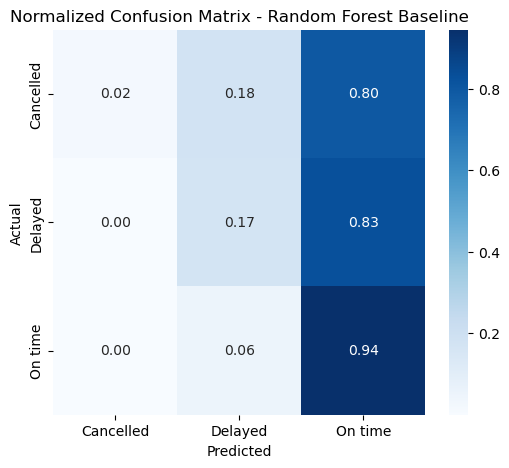


Classification Report:
              precision    recall  f1-score   support

   Cancelled      0.806     0.020     0.039      2719
     Delayed      0.656     0.170     0.270     20122
     On time      0.541     0.944     0.688     23505

    accuracy                          0.554     46346
   macro avg      0.667     0.378     0.332     46346
weighted avg      0.606     0.554     0.468     46346



In [23]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Make predictions on test set
# -----------------------------
y_pred = pipeline.predict(test_df[FEATURES])
y_true = test_df[TARGET]

# -----------------------------
# Step 2: Accuracy
# -----------------------------
acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {acc:.3f}")

# -----------------------------
# Step 3: Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_true, y_pred, labels=pipeline.classes_)
cm_df = pd.DataFrame(cm, index=pipeline.classes_, columns=pipeline.classes_)

print("\nConfusion Matrix (counts):")
print(cm_df)

# Optional: normalized confusion matrix
cm_norm = confusion_matrix(y_true, y_pred, labels=pipeline.classes_, normalize='true')
cm_norm_df = pd.DataFrame(cm_norm, index=pipeline.classes_, columns=pipeline.classes_)

print("\nConfusion Matrix (normalized):")
print(cm_norm_df)

# -----------------------------
# Step 4: Plot normalized confusion matrix
# -----------------------------
plt.figure(figsize=(6,5))
sns.heatmap(cm_norm_df, annot=True, fmt=".2f", cmap="Blues")
plt.title("Normalized Confusion Matrix - Random Forest Baseline")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# -----------------------------
# Step 5: Optional detailed classification report
# -----------------------------
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=3))


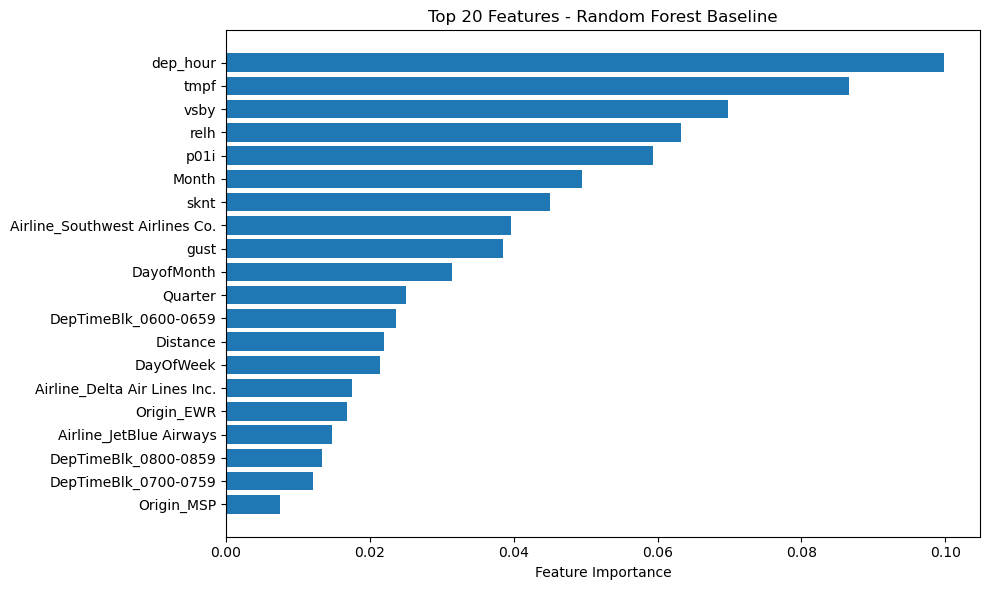

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# STEP 1: Extract feature names after one-hot encoding
# -----------------------------
# Get the preprocessor from the pipeline
preprocessor = pipeline.named_steps["preprocess"]
rf_model = pipeline.named_steps["rf"]

# Get categorical feature names after one-hot
cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
all_features = np.concatenate([cat_features, numeric_features])

# -----------------------------
# STEP 2: Extract feature importances
# -----------------------------
importances = rf_model.feature_importances_

# Sort features by importance
indices = np.argsort(importances)[::-1]
sorted_features = all_features[indices]
sorted_importances = importances[indices]

# -----------------------------
# STEP 3: Plot top 20 features
# -----------------------------
top_n = 20
plt.figure(figsize=(10, 6))
plt.barh(range(top_n), sorted_importances[:top_n][::-1], align="center")
plt.yticks(range(top_n), sorted_features[:top_n][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 20 Features - Random Forest Baseline")
plt.tight_layout()
plt.show()


### Now let's do a more simple Random Forest Model

In [26]:
train_df[FEATURES].head()

,Quarter,Month,DayofMonth,DayOfWeek,dep_hour,DepTimeBlk,Airline,Origin,Dest,Distance,DistanceGroup,tmpf,vsby,sknt,p01i,relh,gust
1802,1,1,1,1,21,2100-2159,JetBlue Airways,BOS,JFK,187.0,1,10.9,10.0,15.571429,0.0,37.75,24.0
9515,1,1,1,1,14,1400-1459,United Air Lines Inc.,EWR,MIA,1085.0,5,12.0,10.0,11.727273,0.0,52.67,20.0
717,1,1,1,1,17,1700-1759,SkyWest Airlines Inc.,LGA,ORD,733.0,3,16.0,10.0,16.000000,0.0,48.57,19.0
1753,1,1,1,1,19,1900-1959,United Air Lines Inc.,IAH,JAX,817.0,4,38.0,10.0,12.000000,0.0,35.35,18.0
7739,1,1,1,1,15,1500-1559,JetBlue Airways,BOS,EWR,200.0,1,7.0,10.0,16.571429,0.0,44.98,26.0


In [27]:
df.tmpf.isna().sum()/df.shape[0]

0.0